In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\revan\Downloads\synthetic_student_performance.csv")

df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,1,3,16,13,0,2,0,0,0,0,3.158425,1
1,1002,18,1,2,0,17,28,0,2,1,1,1,0,2.794655,2
2,1003,15,1,0,1,13,18,1,4,0,0,0,1,3.774847,0
3,1004,17,1,0,3,6,4,0,3,1,0,0,0,3.040574,1
4,1005,17,0,1,2,6,20,0,4,0,0,0,0,3.382310,1


In [2]:
print(df.shape)
print(df.columns)

(5000, 15)
Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')


In [3]:
X = df.drop(["StudentID", "GradeClass"], axis=1)
y = df["GradeClass"]

print(X.shape)
print(y.shape)

(5000, 13)
(5000,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4000, 13)
(1000, 13)


In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print(model)

RandomForestClassifier(random_state=42)


In [6]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[2 0 0 2 2 2 0 2 3 2]


In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.999


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       421
           1       1.00      1.00      1.00       236
           2       1.00      1.00      1.00       204
           3       1.00      0.99      1.00       139

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [9]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

              Feature  Importance
12                GPA    0.740234
4     StudyTimeWeekly    0.066174
5            Absences    0.062727
7     ParentalSupport    0.022695
3   ParentalEducation    0.022288
0                 Age    0.019331
2           Ethnicity    0.016295
9              Sports    0.008831
8     Extracurricular    0.008714
1              Gender    0.008692
11       Volunteering    0.008575
10              Music    0.008429
6            Tutoring    0.007016


In [10]:
weak_students = df[df["GradeClass"] >= 3]

print("Number of weak students:", len(weak_students))

weak_students.head()

Number of weak students: 650


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
12,1013,17,0,0,1,1,14,0,4,0,0,0,0,2.286982,3
24,1025,18,1,0,0,2,18,0,0,0,0,0,1,2.452459,3
42,1043,16,1,1,4,3,12,0,3,1,0,1,1,2.406360,3
44,1045,18,0,0,1,16,27,0,1,0,1,0,0,2.181329,3
47,1048,17,0,0,3,15,28,0,3,1,1,0,0,2.463235,3


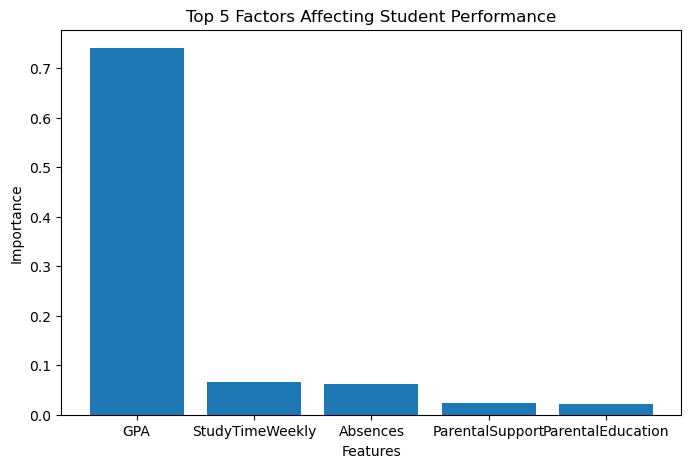

In [11]:
import matplotlib.pyplot as plt

top5 = importance.head(5)

plt.figure(figsize=(8,5))
plt.bar(top5["Feature"], top5["Importance"])
plt.title("Top 5 Factors Affecting Student Performance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()